# 12 Market and Model Probability Discrepancy

## Purpose

This notebook compares Polymarket-implied threshold probabilities with the benchmark probabilities constructed in the previous notebooks.

The main objective is to identify where market prices differ from model-based probabilities at the same information time. This creates the empirical basis for later trading rules, robustness checks and model evaluation.

The notebook uses three probability sources where available:

- market-implied threshold probability from Polymarket bin prices;
- calendar-threshold baseline classifier probability;
- raw weather-forecast benchmark probability.

The realised outcome is the official Hong Kong Observatory threshold-exceedance label created in the threshold-classification dataset.

## 1. Imports and paths

In [4]:
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = Path("../data/raw/market_model_discrepancy")
PROCESSED_DIR = Path("../data/processed/market_model_discrepancy")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 120)

print("Notebook run time UTC:", datetime.now(timezone.utc).isoformat())
print("Processed directory:", PROCESSED_DIR)

Notebook run time UTC: 2026-06-17T06:20:18.384991+00:00
Processed directory: ../data/processed/market_model_discrepancy


## 2. Input files

The preferred input is the Step 9 comparison table, because it already merges Step 7 market probabilities, Step 8 baseline probabilities and Step 9 raw weather benchmark probabilities.

If the preferred table is not found, the notebook tries to build the comparison table from the individual Step 7, Step 8 and Step 9 output files.

In [7]:
INPUT_PATHS = {
    "step7_threshold_dataset": Path("../data/processed/threshold_dataset/hong_kong_threshold_classification_dataset.csv"),
    "step8_baseline_predictions": Path("../data/processed/baseline_classifier/hong_kong_step7_baseline_classifier_predictions.csv"),
    "step9_raw_comparison": Path("../data/processed/raw_weather_benchmark/hong_kong_step7_raw_weather_benchmark_comparison.csv"),
    "step9_raw_threshold_benchmark": Path("../data/processed/raw_weather_benchmark/hong_kong_raw_weather_threshold_benchmark.csv"),
}

for name, path in INPUT_PATHS.items():
    print(f"{name}: {path} | exists={path.exists()}")

step7_threshold_dataset: ../data/processed/threshold_dataset/hong_kong_threshold_classification_dataset.csv | exists=True
step8_baseline_predictions: ../data/processed/baseline_classifier/hong_kong_step7_baseline_classifier_predictions.csv | exists=True
step9_raw_comparison: ../data/processed/raw_weather_benchmark/hong_kong_step7_raw_weather_benchmark_comparison.csv | exists=True
step9_raw_threshold_benchmark: ../data/processed/raw_weather_benchmark/hong_kong_raw_weather_threshold_benchmark.csv | exists=True


## 3. Helper functions

In [10]:
def read_csv_if_exists(path):
    if Path(path).exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def normalise_datetime_columns(df):
    out = df.copy()
    for col in out.columns:
        if col.endswith("_utc") or col in ["target_local_date", "settlement_date_local"]:
            try:
                if col.endswith("_utc"):
                    out[col] = pd.to_datetime(out[col], utc=True, errors="coerce")
                else:
                    out[col] = pd.to_datetime(out[col], errors="coerce")
            except Exception:
                pass
    return out


def clip_probability(p, eps=1e-6):
    return np.clip(pd.to_numeric(p, errors="coerce"), eps, 1 - eps)


def brier_component(y, p):
    y = pd.to_numeric(y, errors="coerce")
    p = pd.to_numeric(p, errors="coerce")
    return (p - y) ** 2


def log_score_component(y, p):
    y = pd.to_numeric(y, errors="coerce")
    p_clip = clip_probability(p)
    return -(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))


def evaluate_probability_column(df, probability_col, label):
    valid = df[["realised_exceeds_threshold", probability_col]].dropna().copy()

    if valid.empty:
        return {
            "probability_source": label,
            "rows": 0,
            "brier_score": np.nan,
            "log_score": np.nan,
            "mean_absolute_error": np.nan,
            "classification_accuracy_0_5": np.nan,
            "average_probability": np.nan,
            "realised_event_rate": np.nan,
        }

    y = valid["realised_exceeds_threshold"].astype(float)
    p = valid[probability_col].astype(float)

    predicted_label = (p >= 0.5).astype(int)

    return {
        "probability_source": label,
        "rows": len(valid),
        "brier_score": float(np.mean((p - y) ** 2)),
        "log_score": float(np.mean(log_score_component(y, p))),
        "mean_absolute_error": float(np.mean(np.abs(p - y))),
        "classification_accuracy_0_5": float(np.mean(predicted_label == y)),
        "average_probability": float(np.mean(p)),
        "realised_event_rate": float(np.mean(y)),
    }

## 4. Load or construct comparison table

In [13]:
step9_comparison_df = read_csv_if_exists(INPUT_PATHS["step9_raw_comparison"])

if not step9_comparison_df.empty:
    comparison_df = step9_comparison_df.copy()
    input_source = "step9_raw_comparison"
else:
    step7_df = read_csv_if_exists(INPUT_PATHS["step7_threshold_dataset"])
    step8_df = read_csv_if_exists(INPUT_PATHS["step8_baseline_predictions"])
    raw_threshold_df = read_csv_if_exists(INPUT_PATHS["step9_raw_threshold_benchmark"])

    if step7_df.empty:
        raise FileNotFoundError(
            "Step 7 threshold dataset not found. Run Notebook 9 before this notebook."
        )

    comparison_df = step7_df.copy()
    input_source = "reconstructed_from_step7_step8_step9"

    if not step8_df.empty:
        step8_keep_cols = [
            c for c in [
                "contract_slug",
                "target_local_date",
                "timing_label",
                "threshold_c",
                "baseline_classifier_probability",
                "baseline_model_name",
            ]
            if c in step8_df.columns
        ]

        comparison_df = comparison_df.merge(
            step8_df[step8_keep_cols].drop_duplicates(),
            on=["contract_slug", "target_local_date", "timing_label", "threshold_c"],
            how="left",
        )

    if not raw_threshold_df.empty and "lead_time_to_day_midpoint_hours" in comparison_df.columns:
        def map_lead_to_previous_run_days(lead_time_hours):
            if pd.isna(lead_time_hours):
                return np.nan
            return int(np.clip(np.round(float(lead_time_hours) / 24), 0, 7))

        comparison_df["lead_time_days_previous_run"] = comparison_df["lead_time_to_day_midpoint_hours"].apply(
            map_lead_to_previous_run_days
        )

        raw_keep_cols = [
            c for c in [
                "lead_time_days_previous_run",
                "threshold_c",
                "raw_forecast_daily_max_c",
                "raw_forecast_threshold_probability",
                "benchmark_type",
            ]
            if c in raw_threshold_df.columns
        ]

        comparison_df = comparison_df.merge(
            raw_threshold_df[raw_keep_cols].drop_duplicates(),
            on=["lead_time_days_previous_run", "threshold_c"],
            how="left",
        )

comparison_df = normalise_datetime_columns(comparison_df)

print("Input source:", input_source)
print("Comparison table shape:", comparison_df.shape)
display(comparison_df.head())

Input source: step9_raw_comparison
Comparison table shape: (40, 37)


,contract_slug,city,target_local_date,settlement_source,settlement_variable,official_realised_temperature_c,threshold_c,realised_exceeds_threshold,forecast_model,forecast_run_time_utc,forecast_issue_time_utc,forecast_valid_time_utc,timing_label,forecast_timing_category,lead_time_to_valid_hours,lead_time_to_day_start_hours,lead_time_to_day_midpoint_hours,lead_time_to_day_end_hours,market_implied_threshold_prob_raw,market_implied_threshold_prob_normalised,number_of_contributing_bins,average_price_time_gap_minutes,market_price_timestamp_rule,forecast_temperature_c,forecast_temperature_source,forecast_feature_status,lead_time_days_previous_run,raw_forecast_daily_max_c,raw_forecast_error_c,raw_forecast_margin_to_threshold_c,raw_forecast_threshold_probability,benchmark_type,baseline_classifier_probability,baseline_model_name,raw_forecast_brier_component,market_brier_component,baseline_brier_component
0,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,24.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9645,0.998964,10,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,6.5,1.0,deterministic_raw_point_forecast,0.992736,logistic_regression_calendar_threshold_baseline,0.0,0.000001,0.000053
1,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,25.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9620,0.996375,9,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,5.5,1.0,deterministic_raw_point_forecast,0.984324,logistic_regression_calendar_threshold_baseline,0.0,0.000013,0.000246
2,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,26.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9595,0.993786,8,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,4.5,1.0,deterministic_raw_point_forecast,0.966503,logistic_regression_calendar_threshold_baseline,0.0,0.000039,0.001122
3,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,27.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9540,0.988089,7,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,3.5,1.0,deterministic_raw_point_forecast,0.929862,logistic_regression_calendar_threshold_baseline,0.0,0.000142,0.004919
4,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,28.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9505,0.984464,6,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,2.5,1.0,deterministic_raw_point_forecast,0.858992,logistic_regression_calendar_threshold_baseline,0.0,0.000241,0.019883


## 5. Validate required columns

The main target column is `realised_exceeds_threshold`. The core probability column is the market-implied threshold probability. The baseline and raw weather probabilities are included where available.

In [16]:
required_cols = [
    "contract_slug",
    "city",
    "target_local_date",
    "timing_label",
    "threshold_c",
    "realised_exceeds_threshold",
    "market_implied_threshold_prob_normalised",
]

missing_required = [c for c in required_cols if c not in comparison_df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

probability_sources = {
    "market": "market_implied_threshold_prob_normalised",
    "baseline_classifier": "baseline_classifier_probability",
    "raw_weather": "raw_forecast_threshold_probability",
}

available_probability_sources = {
    label: col for label, col in probability_sources.items()
    if col in comparison_df.columns and comparison_df[col].notna().any()
}

print("Available probability sources:")
for label, col in available_probability_sources.items():
    print(f"- {label}: {col}")

comparison_df[["timing_label", "threshold_c", "realised_exceeds_threshold"] + list(available_probability_sources.values())].head(20)

Available probability sources:
- market: market_implied_threshold_prob_normalised
- baseline_classifier: baseline_classifier_probability
- raw_weather: raw_forecast_threshold_probability


,timing_label,threshold_c,realised_exceeds_threshold,market_implied_threshold_prob_normalised,baseline_classifier_probability,raw_forecast_threshold_probability
0,two_day_valid_time_example,24.0,1,0.998964,0.992736,1.0
1,two_day_valid_time_example,25.0,1,0.996375,0.984324,1.0
2,two_day_valid_time_example,26.0,1,0.993786,0.966503,1.0
3,two_day_valid_time_example,27.0,1,0.988089,0.929862,1.0
4,two_day_valid_time_example,28.0,1,0.984464,0.858992,1.0
5,two_day_valid_time_example,29.0,1,0.948213,0.736781,1.0
6,two_day_valid_time_example,30.0,1,0.901088,0.562586,1.0
7,two_day_valid_time_example,31.0,1,0.730192,0.371456,0.0
8,two_day_valid_time_example,32.0,1,0.403936,0.213558,0.0
9,two_day_valid_time_example,33.0,0,0.191611,0.110933,0.0


## 6. Probability error and discrepancy columns

This section calculates Brier components, log-score components and pairwise probability discrepancies.

A positive value of `model_minus_market_probability` means the model assigns a higher probability than the market to the threshold event. A negative value means the model assigns a lower probability than the market.

In [19]:
discrepancy_df = comparison_df.copy()

for label, col in available_probability_sources.items():
    discrepancy_df[col] = pd.to_numeric(discrepancy_df[col], errors="coerce")
    discrepancy_df[f"{label}_error"] = (
        discrepancy_df[col] - discrepancy_df["realised_exceeds_threshold"]
    )
    discrepancy_df[f"{label}_abs_error"] = discrepancy_df[f"{label}_error"].abs()
    discrepancy_df[f"{label}_brier_component"] = brier_component(
        discrepancy_df["realised_exceeds_threshold"],
        discrepancy_df[col],
    )
    discrepancy_df[f"{label}_log_score_component"] = log_score_component(
        discrepancy_df["realised_exceeds_threshold"],
        discrepancy_df[col],
    )

if "baseline_classifier_probability" in discrepancy_df.columns:
    discrepancy_df["baseline_minus_market_probability"] = (
        discrepancy_df["baseline_classifier_probability"]
        - discrepancy_df["market_implied_threshold_prob_normalised"]
    )
    discrepancy_df["abs_baseline_minus_market_probability"] = (
        discrepancy_df["baseline_minus_market_probability"].abs()
    )

if "raw_forecast_threshold_probability" in discrepancy_df.columns:
    discrepancy_df["raw_minus_market_probability"] = (
        discrepancy_df["raw_forecast_threshold_probability"]
        - discrepancy_df["market_implied_threshold_prob_normalised"]
    )
    discrepancy_df["abs_raw_minus_market_probability"] = (
        discrepancy_df["raw_minus_market_probability"].abs()
    )

if (
    "baseline_classifier_probability" in discrepancy_df.columns
    and "raw_forecast_threshold_probability" in discrepancy_df.columns
):
    discrepancy_df["raw_minus_baseline_probability"] = (
        discrepancy_df["raw_forecast_threshold_probability"]
        - discrepancy_df["baseline_classifier_probability"]
    )
    discrepancy_df["abs_raw_minus_baseline_probability"] = (
        discrepancy_df["raw_minus_baseline_probability"].abs()
    )

display_cols = [
    c for c in [
        "timing_label",
        "forecast_timing_category",
        "threshold_c",
        "realised_exceeds_threshold",
        "market_implied_threshold_prob_normalised",
        "baseline_classifier_probability",
        "raw_forecast_threshold_probability",
        "baseline_minus_market_probability",
        "raw_minus_market_probability",
        "market_brier_component",
        "baseline_classifier_brier_component",
        "raw_weather_brier_component",
    ]
    if c in discrepancy_df.columns
]

discrepancy_df[display_cols].head(40)

,timing_label,forecast_timing_category,threshold_c,realised_exceeds_threshold,market_implied_threshold_prob_normalised,baseline_classifier_probability,raw_forecast_threshold_probability,baseline_minus_market_probability,raw_minus_market_probability,market_brier_component,baseline_classifier_brier_component,raw_weather_brier_component
0,two_day_valid_time_example,full_day_ex_ante,24.0,1,0.998964,0.992736,1.0,-0.006229,0.001036,1.072742e-06,0.000053,0.0
1,two_day_valid_time_example,full_day_ex_ante,25.0,1,0.996375,0.984324,1.0,-0.012050,0.003625,1.314109e-05,0.000246,0.0
2,two_day_valid_time_example,full_day_ex_ante,26.0,1,0.993786,0.966503,1.0,-0.027283,0.006214,3.861873e-05,0.001122,0.0
3,two_day_valid_time_example,full_day_ex_ante,27.0,1,0.988089,0.929862,1.0,-0.058227,0.011911,1.418702e-04,0.004919,0.0
4,two_day_valid_time_example,full_day_ex_ante,28.0,1,0.984464,0.858992,1.0,-0.125472,0.015536,2.413670e-04,0.019883,0.0
5,two_day_valid_time_example,full_day_ex_ante,29.0,1,0.948213,0.736781,1.0,-0.211433,0.051787,2.681856e-03,0.069284,0.0
6,two_day_valid_time_example,full_day_ex_ante,30.0,1,0.901088,0.562586,1.0,-0.338502,0.098912,9.783679e-03,0.191331,0.0
7,two_day_valid_time_example,full_day_ex_ante,31.0,1,0.730192,0.371456,0.0,-0.358735,-0.730192,7.279657e-02,0.395067,1.0
8,two_day_valid_time_example,full_day_ex_ante,32.0,1,0.403936,0.213558,0.0,-0.190378,-0.403936,3.552925e-01,0.618492,1.0
9,two_day_valid_time_example,full_day_ex_ante,33.0,0,0.191611,0.110933,0.0,-0.080678,-0.191611,3.671461e-02,0.012306,0.0


## 7. Overall probability metrics

In [22]:
metric_rows = []

for label, col in available_probability_sources.items():
    metric_rows.append(evaluate_probability_column(discrepancy_df, col, label))

metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values("brier_score", na_position="last")
    .reset_index(drop=True)
)

metrics_df

,probability_source,rows,brier_score,log_score,mean_absolute_error,classification_accuracy_0_5,average_probability,realised_event_rate
0,market,40,0.052922,0.162932,0.115390,0.900,0.808516,0.9
1,baseline_classifier,40,0.131270,0.381431,0.249414,0.800,0.672773,0.9
2,raw_weather,40,0.225000,3.108491,0.225000,0.775,0.675000,0.9


## 8. Discrepancy summaries by threshold and timing

In [25]:
threshold_agg = {
    "rows": ("realised_exceeds_threshold", "size"),
    "realised_event_rate": ("realised_exceeds_threshold", "mean"),
    "market_probability_mean": ("market_implied_threshold_prob_normalised", "mean"),
    "market_brier_mean": ("market_brier_component", "mean"),
}

if "baseline_classifier_probability" in discrepancy_df.columns:
    threshold_agg.update({
        "baseline_probability_mean": ("baseline_classifier_probability", "mean"),
        "baseline_brier_mean": ("baseline_classifier_brier_component", "mean"),
        "abs_baseline_minus_market_mean": ("abs_baseline_minus_market_probability", "mean"),
    })

if "raw_forecast_threshold_probability" in discrepancy_df.columns:
    threshold_agg.update({
        "raw_probability_mean": ("raw_forecast_threshold_probability", "mean"),
        "raw_brier_mean": ("raw_weather_brier_component", "mean"),
        "abs_raw_minus_market_mean": ("abs_raw_minus_market_probability", "mean"),
    })

discrepancy_by_threshold_df = (
    discrepancy_df
    .groupby("threshold_c", dropna=False)
    .agg(**threshold_agg)
    .reset_index()
    .sort_values("threshold_c")
)

discrepancy_by_threshold_df

,threshold_c,rows,realised_event_rate,market_probability_mean,market_brier_mean,baseline_probability_mean,baseline_brier_mean,abs_baseline_minus_market_mean,raw_probability_mean,raw_brier_mean,abs_raw_minus_market_mean
0,24.0,4,1.0,0.999383,4.390335e-07,0.992736,0.000053,0.006647,1.00,0.00,0.000617
1,25.0,4,1.0,0.998378,3.968665e-06,0.984324,0.000246,0.014053,1.00,0.00,0.001622
2,26.0,4,1.0,0.997373,1.119231e-05,0.966503,0.001122,0.030870,1.00,0.00,0.002627
3,27.0,4,1.0,0.995233,3.984924e-05,0.929862,0.004919,0.065371,1.00,0.00,0.004767
4,28.0,4,1.0,0.993611,6.916060e-05,0.858992,0.019883,0.134620,1.00,0.00,0.006389
5,29.0,4,1.0,0.979409,7.670688e-04,0.736781,0.069284,0.242628,1.00,0.00,0.020591
6,30.0,4,1.0,0.932691,5.277962e-03,0.562586,0.191331,0.370105,0.50,0.50,0.525856
7,31.0,4,1.0,0.724095,7.672253e-02,0.371456,0.395067,0.352638,0.25,0.75,0.623470
8,32.0,4,1.0,0.345457,4.301516e-01,0.213558,0.618492,0.131899,0.00,1.00,0.345457
9,33.0,4,0.0,0.119529,1.617400e-02,0.110933,0.012306,0.033692,0.00,0.00,0.119529


In [27]:
timing_group_cols = [
    c for c in ["timing_label", "forecast_timing_category"]
    if c in discrepancy_df.columns
]

timing_agg = {
    "rows": ("realised_exceeds_threshold", "size"),
    "realised_event_rate": ("realised_exceeds_threshold", "mean"),
    "market_brier_mean": ("market_brier_component", "mean"),
    "market_probability_mean": ("market_implied_threshold_prob_normalised", "mean"),
}

if "baseline_classifier_probability" in discrepancy_df.columns:
    timing_agg.update({
        "baseline_brier_mean": ("baseline_classifier_brier_component", "mean"),
        "baseline_probability_mean": ("baseline_classifier_probability", "mean"),
        "abs_baseline_minus_market_mean": ("abs_baseline_minus_market_probability", "mean"),
    })

if "raw_forecast_threshold_probability" in discrepancy_df.columns:
    timing_agg.update({
        "raw_brier_mean": ("raw_weather_brier_component", "mean"),
        "raw_probability_mean": ("raw_forecast_threshold_probability", "mean"),
        "abs_raw_minus_market_mean": ("abs_raw_minus_market_probability", "mean"),
    })

discrepancy_by_timing_df = (
    discrepancy_df
    .groupby(timing_group_cols, dropna=False)
    .agg(**timing_agg)
    .reset_index()
)

discrepancy_by_timing_df

,timing_label,forecast_timing_category,rows,realised_event_rate,market_brier_mean,market_probability_mean,baseline_brier_mean,baseline_probability_mean,abs_baseline_minus_market_mean,raw_brier_mean,raw_probability_mean,abs_raw_minus_market_mean
0,one_and_half_day_valid_time_example,full_day_ex_ante,10,0.9,0.054661,0.807321,0.13127,0.672773,0.134548,0.3,0.6,0.212775
1,one_day_valid_time_example,full_day_ex_ante,10,0.9,0.048059,0.815184,0.13127,0.672773,0.148515,0.3,0.6,0.218117
2,same_day_valid_time_example,within_day_update,10,0.9,0.061197,0.797887,0.13127,0.672773,0.129048,0.1,0.8,0.078002
3,two_day_valid_time_example,full_day_ex_ante,10,0.9,0.047771,0.813672,0.13127,0.672773,0.140899,0.2,0.7,0.151476


## 9. Largest market-model disagreements

The rows below identify where model probabilities and market probabilities differ most. These rows are useful for later trading-rule design, but they should not be interpreted as profitable opportunities without liquidity, transaction-cost and robustness checks.

In [30]:
disagreement_cols = [
    c for c in [
        "contract_slug",
        "city",
        "target_local_date",
        "timing_label",
        "forecast_timing_category",
        "threshold_c",
        "realised_exceeds_threshold",
        "market_implied_threshold_prob_normalised",
        "baseline_classifier_probability",
        "raw_forecast_threshold_probability",
        "baseline_minus_market_probability",
        "raw_minus_market_probability",
        "abs_baseline_minus_market_probability",
        "abs_raw_minus_market_probability",
        "market_price_time_utc",
        "forecast_issue_time_utc",
        "price_time_gap_minutes",
    ]
    if c in discrepancy_df.columns
]

sort_col = None
if "abs_raw_minus_market_probability" in discrepancy_df.columns:
    sort_col = "abs_raw_minus_market_probability"
elif "abs_baseline_minus_market_probability" in discrepancy_df.columns:
    sort_col = "abs_baseline_minus_market_probability"

if sort_col is not None:
    largest_disagreements_df = (
        discrepancy_df[disagreement_cols]
        .sort_values(sort_col, ascending=False)
        .reset_index(drop=True)
    )
else:
    largest_disagreements_df = pd.DataFrame()

largest_disagreements_df.head(20)

,contract_slug,city,target_local_date,timing_label,forecast_timing_category,threshold_c,realised_exceeds_threshold,market_implied_threshold_prob_normalised,baseline_classifier_probability,raw_forecast_threshold_probability,baseline_minus_market_probability,raw_minus_market_probability,abs_baseline_minus_market_probability,abs_raw_minus_market_probability,forecast_issue_time_utc
0,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,one_day_valid_time_example,full_day_ex_ante,30.0,1,0.969726,0.562586,0.0,-0.407140,-0.969726,0.407140,0.969726,2026-05-29 12:00:00+00:00
1,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,one_and_half_day_valid_time_example,full_day_ex_ante,30.0,1,0.947368,0.562586,0.0,-0.384782,-0.947368,0.384782,0.947368,2026-05-29 00:00:00+00:00
2,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,one_day_valid_time_example,full_day_ex_ante,31.0,1,0.761589,0.371456,0.0,-0.390133,-0.761589,0.390133,0.761589,2026-05-29 12:00:00+00:00
3,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,31.0,1,0.730192,0.371456,0.0,-0.358735,-0.730192,0.358735,0.730192,2026-05-28 12:00:00+00:00
4,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,one_and_half_day_valid_time_example,full_day_ex_ante,31.0,1,0.703349,0.371456,0.0,-0.331893,-0.703349,0.331893,0.703349,2026-05-29 00:00:00+00:00
5,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,32.0,1,0.403936,0.213558,0.0,-0.190378,-0.403936,0.190378,0.403936,2026-05-28 12:00:00+00:00
6,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,one_day_valid_time_example,full_day_ex_ante,32.0,1,0.354778,0.213558,0.0,-0.141220,-0.354778,0.141220,0.354778,2026-05-29 12:00:00+00:00
7,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,one_and_half_day_valid_time_example,full_day_ex_ante,32.0,1,0.334928,0.213558,0.0,-0.121371,-0.334928,0.121371,0.334928,2026-05-29 00:00:00+00:00
8,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,same_day_valid_time_example,within_day_update,31.0,1,0.701249,0.371456,1.0,-0.329792,0.298751,0.329792,0.298751,2026-05-30 00:00:00+00:00
9,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,same_day_valid_time_example,within_day_update,32.0,1,0.288184,0.213558,0.0,-0.074627,-0.288184,0.074627,0.288184,2026-05-30 00:00:00+00:00


## 10. Visual diagnostics

The plots are simple diagnostics for the single Hong Kong example. They are not intended as final statistical evidence, but they make probability discrepancies easier to inspect.

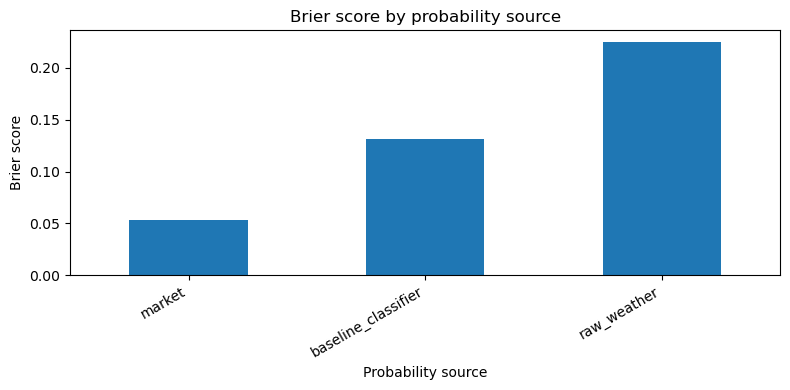

In [33]:
if not metrics_df.empty:
    ax = metrics_df.plot(
        x="probability_source",
        y="brier_score",
        kind="bar",
        legend=False,
        title="Brier score by probability source",
        figsize=(8, 4),
    )
    ax.set_xlabel("Probability source")
    ax.set_ylabel("Brier score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

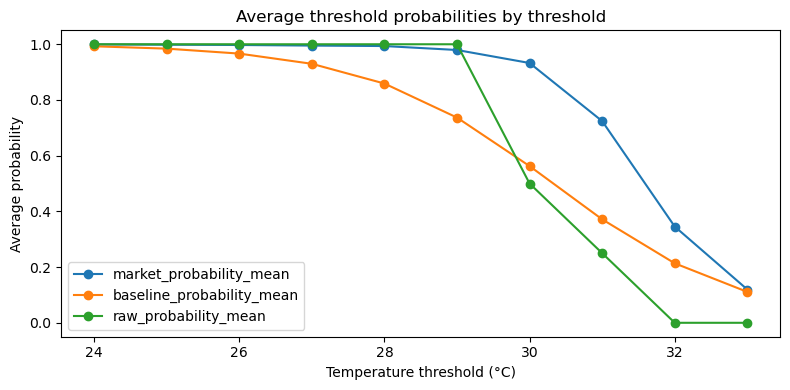

In [35]:
plot_cols = ["threshold_c", "market_probability_mean"]

if "baseline_probability_mean" in discrepancy_by_threshold_df.columns:
    plot_cols.append("baseline_probability_mean")

if "raw_probability_mean" in discrepancy_by_threshold_df.columns:
    plot_cols.append("raw_probability_mean")

if len(plot_cols) > 2:
    ax = discrepancy_by_threshold_df[plot_cols].plot(
        x="threshold_c",
        title="Average threshold probabilities by threshold",
        figsize=(8, 4),
        marker="o",
    )
    ax.set_xlabel("Temperature threshold (°C)")
    ax.set_ylabel("Average probability")
    plt.tight_layout()
    plt.show()

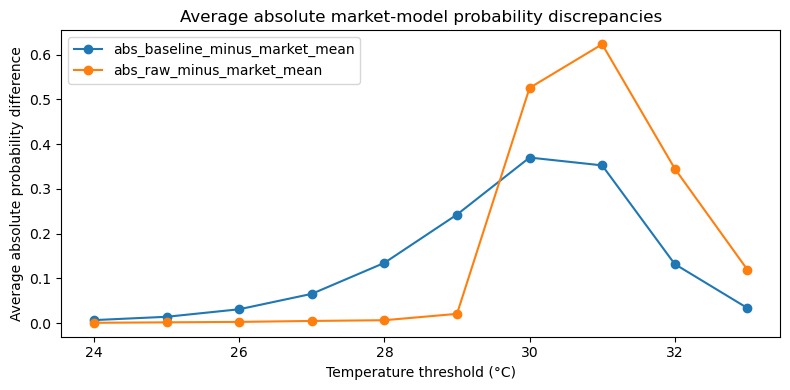

In [37]:
plot_cols = ["threshold_c"]

if "abs_baseline_minus_market_mean" in discrepancy_by_threshold_df.columns:
    plot_cols.append("abs_baseline_minus_market_mean")

if "abs_raw_minus_market_mean" in discrepancy_by_threshold_df.columns:
    plot_cols.append("abs_raw_minus_market_mean")

if len(plot_cols) > 1:
    ax = discrepancy_by_threshold_df[plot_cols].plot(
        x="threshold_c",
        title="Average absolute market-model probability discrepancies",
        figsize=(8, 4),
        marker="o",
    )
    ax.set_xlabel("Temperature threshold (°C)")
    ax.set_ylabel("Average absolute probability difference")
    plt.tight_layout()
    plt.show()

## 11. Save outputs

In [40]:
discrepancy_output_path = PROCESSED_DIR / "hong_kong_market_model_probability_discrepancy.csv"
metrics_output_path = PROCESSED_DIR / "hong_kong_market_model_probability_metrics.csv"
threshold_summary_output_path = PROCESSED_DIR / "hong_kong_discrepancy_by_threshold.csv"
timing_summary_output_path = PROCESSED_DIR / "hong_kong_discrepancy_by_timing.csv"
largest_disagreements_output_path = PROCESSED_DIR / "hong_kong_largest_market_model_disagreements.csv"

discrepancy_df.to_csv(discrepancy_output_path, index=False)
metrics_df.to_csv(metrics_output_path, index=False)
discrepancy_by_threshold_df.to_csv(threshold_summary_output_path, index=False)
discrepancy_by_timing_df.to_csv(timing_summary_output_path, index=False)

if not largest_disagreements_df.empty:
    largest_disagreements_df.to_csv(largest_disagreements_output_path, index=False)

print("Saved discrepancy table:", discrepancy_output_path)
print("Saved probability metrics:", metrics_output_path)
print("Saved threshold summary:", threshold_summary_output_path)
print("Saved timing summary:", timing_summary_output_path)

if not largest_disagreements_df.empty:
    print("Saved largest disagreements:", largest_disagreements_output_path)

Saved discrepancy table: ../data/processed/market_model_discrepancy/hong_kong_market_model_probability_discrepancy.csv
Saved probability metrics: ../data/processed/market_model_discrepancy/hong_kong_market_model_probability_metrics.csv
Saved threshold summary: ../data/processed/market_model_discrepancy/hong_kong_discrepancy_by_threshold.csv
Saved timing summary: ../data/processed/market_model_discrepancy/hong_kong_discrepancy_by_timing.csv
Saved largest disagreements: ../data/processed/market_model_discrepancy/hong_kong_largest_market_model_disagreements.csv


## 12. Interpretation

This notebook compares market-implied threshold probabilities with benchmark model probabilities at the same information time.

For the current Hong Kong example, the comparison is based on one realised event expanded across forecast timings and thresholds. Therefore, the results should be interpreted as a pipeline diagnostic rather than final evidence about market efficiency or model superiority.

The key output is the discrepancy table. It records where the market assigns higher or lower probabilities than the baseline classifier or raw weather benchmark. These discrepancies are the natural starting point for later trading-rule design, because a trading signal would be based on the difference between a model-implied probability and the market-implied probability.

The comparison must remain time-aligned. The market probability should be sampled at the forecast issue time or the first available market timestamp after that issue time. The realised official temperature should only be used afterwards for scoring.

The next stage is to convert these probability discrepancies into a simple binary trading rule, then test robustness to thresholds, timing choices, transaction costs and market liquidity.